In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/supermarket_sales.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 17


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [6]:
print(df.dtypes)

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [9]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [11]:
print("Branch counts:")
print(df["Branch"].value_counts())

Branch counts:
Branch
A    340
B    332
C    328
Name: count, dtype: int64


In [12]:
print("\nCity counts:")
print(df["City"].value_counts())


City counts:
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64


In [13]:
print("\nGender counts:")
print(df["Gender"].value_counts())


Gender counts:
Gender
Female    501
Male      499
Name: count, dtype: int64


In [14]:
print("\nCustomer type counts:")
print(df["Customer type"].value_counts())


Customer type counts:
Customer type
Member    501
Normal    499
Name: count, dtype: int64


In [15]:
print("\nPayment method counts:")
print(df["Payment"].value_counts())


Payment method counts:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


In [16]:
print("Product lines:")
print(df["Product line"].value_counts())

Product lines:
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64


In [17]:
product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64


In [18]:
print("Highest selling product line:")
print(product_sales.idxmax())

print("Highest total sales:")
print(product_sales.max())

Highest selling product line:
Food and beverages
Highest total sales:
56144.844


In [19]:
branch_sales = df.groupby("Branch")["Total"].sum().sort_values(ascending=False)

print(branch_sales)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


In [20]:
print("Branch with highest sales:")
print(branch_sales.idxmax())

Branch with highest sales:
C


In [21]:
city_sales = df.groupby("City")["Total"].sum().sort_values(ascending=False)

print(city_sales)

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Total, dtype: float64


In [22]:
print("City with highest sales:")
print(city_sales.idxmax())

City with highest sales:
Naypyitaw


In [23]:
average_rating = df["Rating"].mean()

print("Average customer rating:", round(average_rating, 2))

Average customer rating: 6.97


In [24]:
print("Average quantity purchased:",
      round(df["Quantity"].mean(), 2))

print("Minimum quantity:",
      df["Quantity"].min())

print("Maximum quantity:",
      df["Quantity"].max())

Average quantity purchased: 5.51
Minimum quantity: 1
Maximum quantity: 10


In [25]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [26]:
df["Month"] = df["Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Total"].sum()

print(monthly_sales)

Month
February     97219.374
January     116291.868
March       109455.507
Name: Total, dtype: float64


In [27]:
print("Month with highest sales:")
print(monthly_sales.idxmax())

print("Highest monthly sales:")
print(monthly_sales.max())

Month with highest sales:
January
Highest monthly sales:
116291.868


In [28]:
print("Quantity statistics:")
print(df["Quantity"].describe())

Quantity statistics:
count    1000.000000
mean        5.510000
std         2.923431
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Quantity, dtype: float64


In [29]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Quantity"] < lower_limit) |
    (df["Quantity"] > upper_limit)
]

print("Number of quantity outliers:", len(outliers))

Number of quantity outliers: 0


In [30]:
print("1. Highest selling product line:",
      df.groupby("Product line")["Total"].sum().idxmax())

1. Highest selling product line: Food and beverages


In [31]:
print("2. Highest selling branch:",
      df.groupby("Branch")["Total"].sum().idxmax())

2. Highest selling branch: C


In [32]:
print("3. Most common payment method:",
      df["Payment"].value_counts().idxmax())

3. Most common payment method: Ewallet


In [33]:
print("4. Gender with more transactions:",
      df["Gender"].value_counts().idxmax())

4. Gender with more transactions: Female


In [34]:
print("5. Average customer rating:",
      round(df["Rating"].mean(), 2))

5. Average customer rating: 6.97


In [35]:
print("6. Highest sales month:",
      df.groupby("Month")["Total"].sum().idxmax())

6. Highest sales month: January


In [36]:
print("========== TASK 2 EDA SUMMARY ==========")

print("Total transactions:", len(df))

print("Total sales:", round(df["Total"].sum(), 2))

print("Average transaction value:",
      round(df["Total"].mean(), 2))

print("Highest selling product line:",
      df.groupby("Product line")["Total"].sum().idxmax())

print("Highest selling branch:",
      df.groupby("Branch")["Total"].sum().idxmax())

print("Most common payment method:",
      df["Payment"].value_counts().idxmax())

print("Average customer rating:",
      round(df["Rating"].mean(), 2))

print("Missing values:",
      df.isnull().sum().sum())

print("Duplicate rows:",
      df.duplicated().sum())

========== TASK 2 EDA SUMMARY ==========
Total transactions: 1000
Total sales: 322966.75
Average transaction value: 322.97
Highest selling product line: Food and beverages
Highest selling branch: C
Most common payment method: Ewallet
Average customer rating: 6.97
Missing values: 0
Duplicate rows: 0


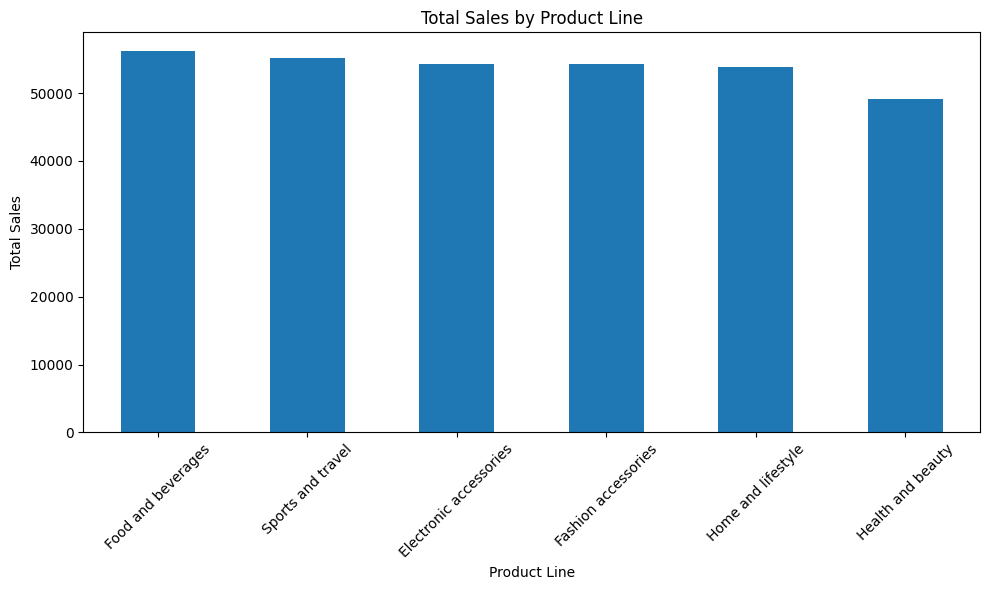

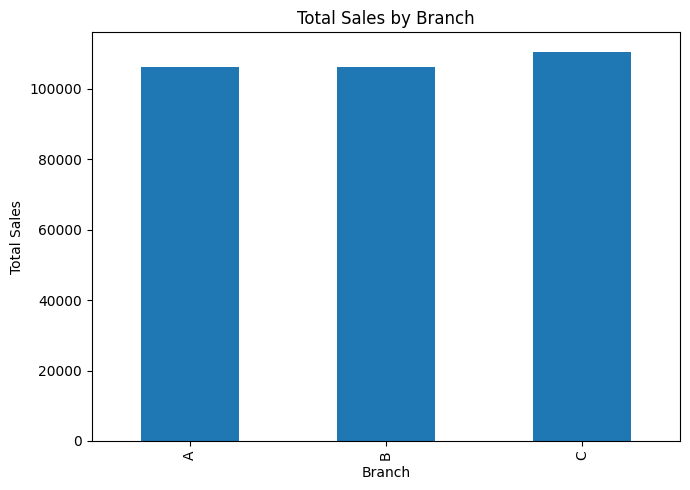

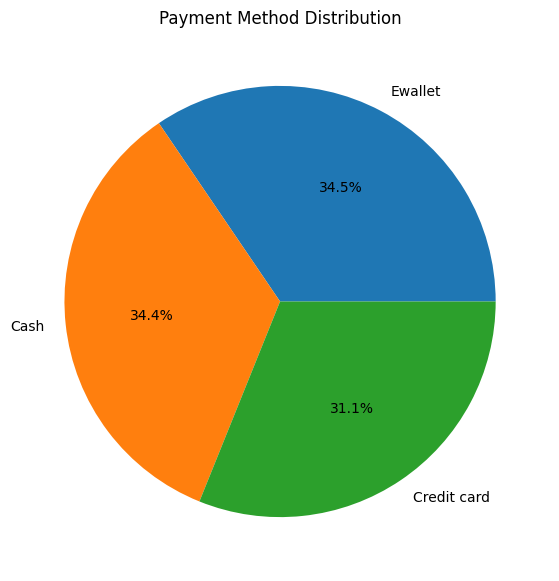

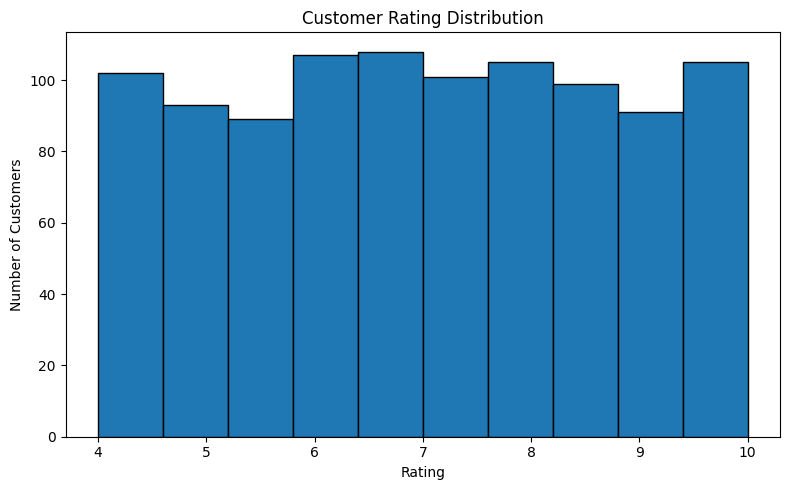

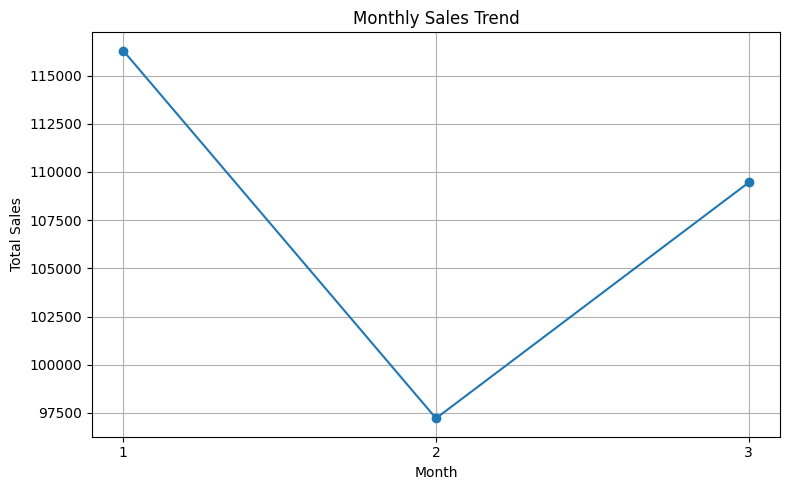

In [37]:
# ==========================================
# TASK 3 - DATA VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sales by Product Line
product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Sales by Branch
branch_sales = df.groupby("Branch")["Total"].sum()

plt.figure(figsize=(7, 5))
branch_sales.plot(kind="bar")
plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


# 3. Payment Method Distribution
payment_counts = df["Payment"].value_counts()

plt.figure(figsize=(7, 7))
payment_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


# 4. Customer Rating Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Rating"], bins=10, edgecolor="black")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# 5. Sales by Month
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Total"].sum()

plt.figure(figsize=(8, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(monthly_sales.index)
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 3 - Data Visualization

### 1. Sales by Product Line
This chart shows the total sales for each product line. Food and beverages has the highest sales.

### 2. Sales by Branch
This chart compares the total sales of the three branches. Branch C has the highest sales.

### 3. Payment Method Distribution
This chart shows the distribution of payment methods. Ewallet is the most commonly used payment method.

### 4. Customer Rating Distribution
This histogram shows the distribution of customer ratings. The average customer rating is 6.97.

### 5. Monthly Sales Trend
This line chart shows how total sales change across the months.

## Task 3 Conclusion

Data visualization makes the sales data easier to understand. The charts help identify important sales patterns, customer behaviour, and trends.